In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
df = pd.read_csv('insurance.csv')

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# Convert text (categorical) to numbers
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [ ]:
X = df.drop('charges', axis=1)
y = df['charges']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² Score: {r2}")
print(f"Mean Absolute Error: ₹{int(mae)}")

R² Score: 0.8666060896739511
Mean Absolute Error: ₹2529


In [ ]:
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})
comparison.head(10)

,Actual Charges,Predicted Charges
0,9095.06825,10052.387150
1,5272.17580,5562.790515
2,29330.98315,28154.104981
3,9301.89355,12517.332674
4,33750.29180,34667.532992
5,4536.25900,8206.112162
6,2117.33885,2108.645340
7,14210.53595,14433.449085
8,3732.62510,6170.606357
9,10264.44210,10782.185903


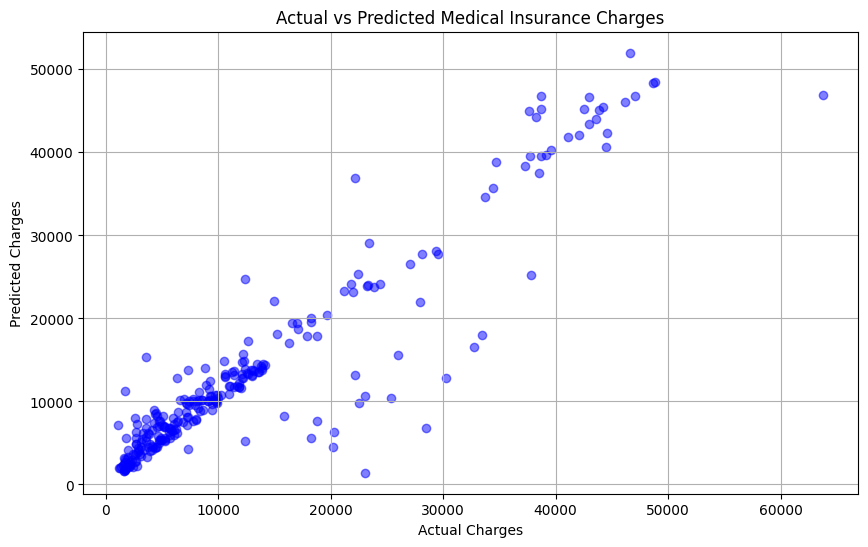

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Insurance Charges")
plt.grid(True)
plt.show()

In [ ]:
# Step 9: Save the trained model for Streamlit
joblib.dump(model, 'insurance_model.pkl')

['insurance_model.pkl']